In [1]:

# ── CELL 1: Mount Drive ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/article_data")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "font.family":       "Liberation Sans",
    "font.size":         9,
    "font.weight":       "normal",
    "axes.titleweight":  "normal",
    "axes.labelweight":  "normal",
    "axes.linewidth":    0.8,
    "lines.linewidth":   1.0,
    "legend.frameon":    False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        300,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.05,
})

C_BLUE   = "#4472C4"
C_RED    = "#C00000"
C_ORANGE = "#ED7D31"
C_GREEN  = "#70AD47"
C_GREY   = "#888888"



Mounted at /content/drive


In [2]:

# ── CELL 2: Load data and probabilities ──────────────────────
test_df = pd.read_parquet(DATA_DIR / "test.parquet")
y_test  = test_df["high_risk"].values
n_test  = len(y_test)
n_pos   = y_test.sum()
base_rate = y_test.mean()

print(f"Test set: {n_test:,} records")
print(f"High-risk: {n_pos:,} ({base_rate*100:.2f}%)")

# Load M1 original probabilities (from colab_03)
# If not saved separately, rebuild quickly
try:
    m1_probs = np.load(DATA_DIR / "m1_test_probs_orig.npy")
    print("M1 original probs loaded from Drive")
except:
    print("Rebuilding M1 original probabilities...")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    train_df = pd.read_parquet(DATA_DIR / "train.parquet")
    X_train = train_df["text_full"].fillna("").values
    X_test  = test_df["text_full"].fillna("").values
    y_train = train_df["high_risk"].values
    tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                             sublinear_tf=True, min_df=2)
    X_tr = tfidf.fit_transform(X_train)
    X_te = tfidf.transform(X_test)
    lr = LogisticRegression(C=1.0, max_iter=1000,
                             class_weight="balanced",
                             random_state=42, solver="saga", n_jobs=-1)
    lr.fit(X_tr, y_train)
    m1_probs = lr.predict_proba(X_te)[:,1]
    np.save(DATA_DIR / "m1_test_probs_orig.npy", m1_probs)
    print(f"M1 probs computed and saved. Shape: {m1_probs.shape}")

# Load M2 and M3 probs if available
try:
    m3_probs = np.load(DATA_DIR / "m3_test_probs.npy")
    print(f"M3 probs loaded. Shape: {m3_probs.shape}")
    has_m3 = True
except:
    print("M3 probs not found — skip M3 in comparisons")
    has_m3 = False

try:
    # Rebuild M2 from embeddings
    import xgboost as xgb
    emb_tr = np.load(DATA_DIR / "emb_train.npy")
    emb_te = np.load(DATA_DIR / "emb_test.npy")
    train_df2 = pd.read_parquet(DATA_DIR / "train.parquet")
    y_train2  = train_df2["high_risk"].values
    neg = (y_train2==0).sum(); pos = (y_train2==1).sum()
    xgb_clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg/pos, random_state=42,
        n_jobs=-1, verbosity=0)
    xgb_clf.fit(emb_tr, y_train2)
    m2_probs = xgb_clf.predict_proba(emb_te)[:,1]
    np.save(DATA_DIR / "m2_test_probs.npy", m2_probs)
    print(f"M2 probs computed. AUC check:")
    from sklearn.metrics import roc_auc_score
    print(f"  M2 AUC: {roc_auc_score(y_test, m2_probs):.4f}")
    has_m2 = True
except Exception as e:
    print(f"M2 not available: {e}")
    has_m2 = False



Test set: 41,413 records
High-risk: 549 (1.33%)
Rebuilding M1 original probabilities...
M1 probs computed and saved. Shape: (41413,)
M3 probs loaded. Shape: (41413,)
M2 probs computed. AUC check:
  M2 AUC: 0.8323


In [3]:

# ── CELL 3: Precision@k computation ──────────────────────────
def precision_at_k(y_true, y_prob, k_pct):
    """Precision at top-k% by predicted probability."""
    k = max(1, int(len(y_true) * k_pct / 100))
    top_idx = np.argsort(y_prob)[::-1][:k]
    return y_true[top_idx].mean(), k

def effort_coverage(y_true, y_prob):
    """
    Returns (effort, coverage) arrays for plotting.
    effort  = fraction of all CVEs reviewed (x-axis)
    coverage = fraction of high-risk CVEs found (y-axis)
    """
    sorted_idx = np.argsort(y_prob)[::-1]
    n = len(y_true)
    n_pos = y_true.sum()
    cumulative_pos = np.cumsum(y_true[sorted_idx])
    effort   = np.arange(1, n+1) / n * 100
    coverage = cumulative_pos / n_pos * 100
    return effort, coverage

print("\n=== PRECISION@k (M1 original) ===")
print(f"Baseline (random): {base_rate*100:.2f}%")
print(f"{'k%':<8} {'k (CVEs)':>10} {'Precision':>12} {'Lift':>8}")
print("-" * 42)

pk_results = {}
for k_pct in [1, 2, 5, 10, 20]:
    prec, k_n = precision_at_k(y_test, m1_probs, k_pct)
    lift = prec / base_rate
    pk_results[k_pct] = {"prec": prec, "k_n": k_n, "lift": lift}
    print(f"{k_pct:<8} {k_n:>10,} {prec*100:>11.1f}% {lift:>7.1f}x")




=== PRECISION@k (M1 original) ===
Baseline (random): 1.33%
k%         k (CVEs)    Precision     Lift
------------------------------------------
1               414        21.0%    15.9x
2               828        17.8%    13.4x
5             2,070        12.1%     9.1x
10            4,141         8.3%     6.3x
20            8,282         5.1%     3.9x


In [4]:

# ── CELL 4: Precision@k for all models ───────────────────────
print("\n=== PRECISION@k — ALL MODELS ===")
print(f"{'Method':<20} {'@1%':>8} {'@2%':>8} {'@5%':>8} {'@10%':>8} {'@20%':>8}")
print("-"*60)

models = {"M1: TF-IDF+LR": m1_probs}
if has_m2:
    models["M2: SBERT+XGB"] = m2_probs
if has_m3:
    models["M3: SecBERT FT"] = m3_probs

for name, probs in models.items():
    row = name
    vals = []
    for k_pct in [1, 2, 5, 10, 20]:
        prec, _ = precision_at_k(y_test, probs, k_pct)
        vals.append(prec)
    print(f"{row:<20} " +
          " ".join(f"{v*100:>7.1f}%" for v in vals))

print(f"\nBaseline (random): " +
      " ".join(f"{base_rate*100:>7.1f}%" for _ in range(5)))




=== PRECISION@k — ALL MODELS ===
Method                    @1%      @2%      @5%     @10%     @20%
------------------------------------------------------------
M1: TF-IDF+LR           21.0%    17.8%    12.1%     8.3%     5.1%
M2: SBERT+XGB           14.3%    12.3%     8.9%     6.5%     4.6%
M3: SecBERT FT          19.1%    16.4%    11.8%     7.9%     5.2%

Baseline (random):     1.3%     1.3%     1.3%     1.3%     1.3%


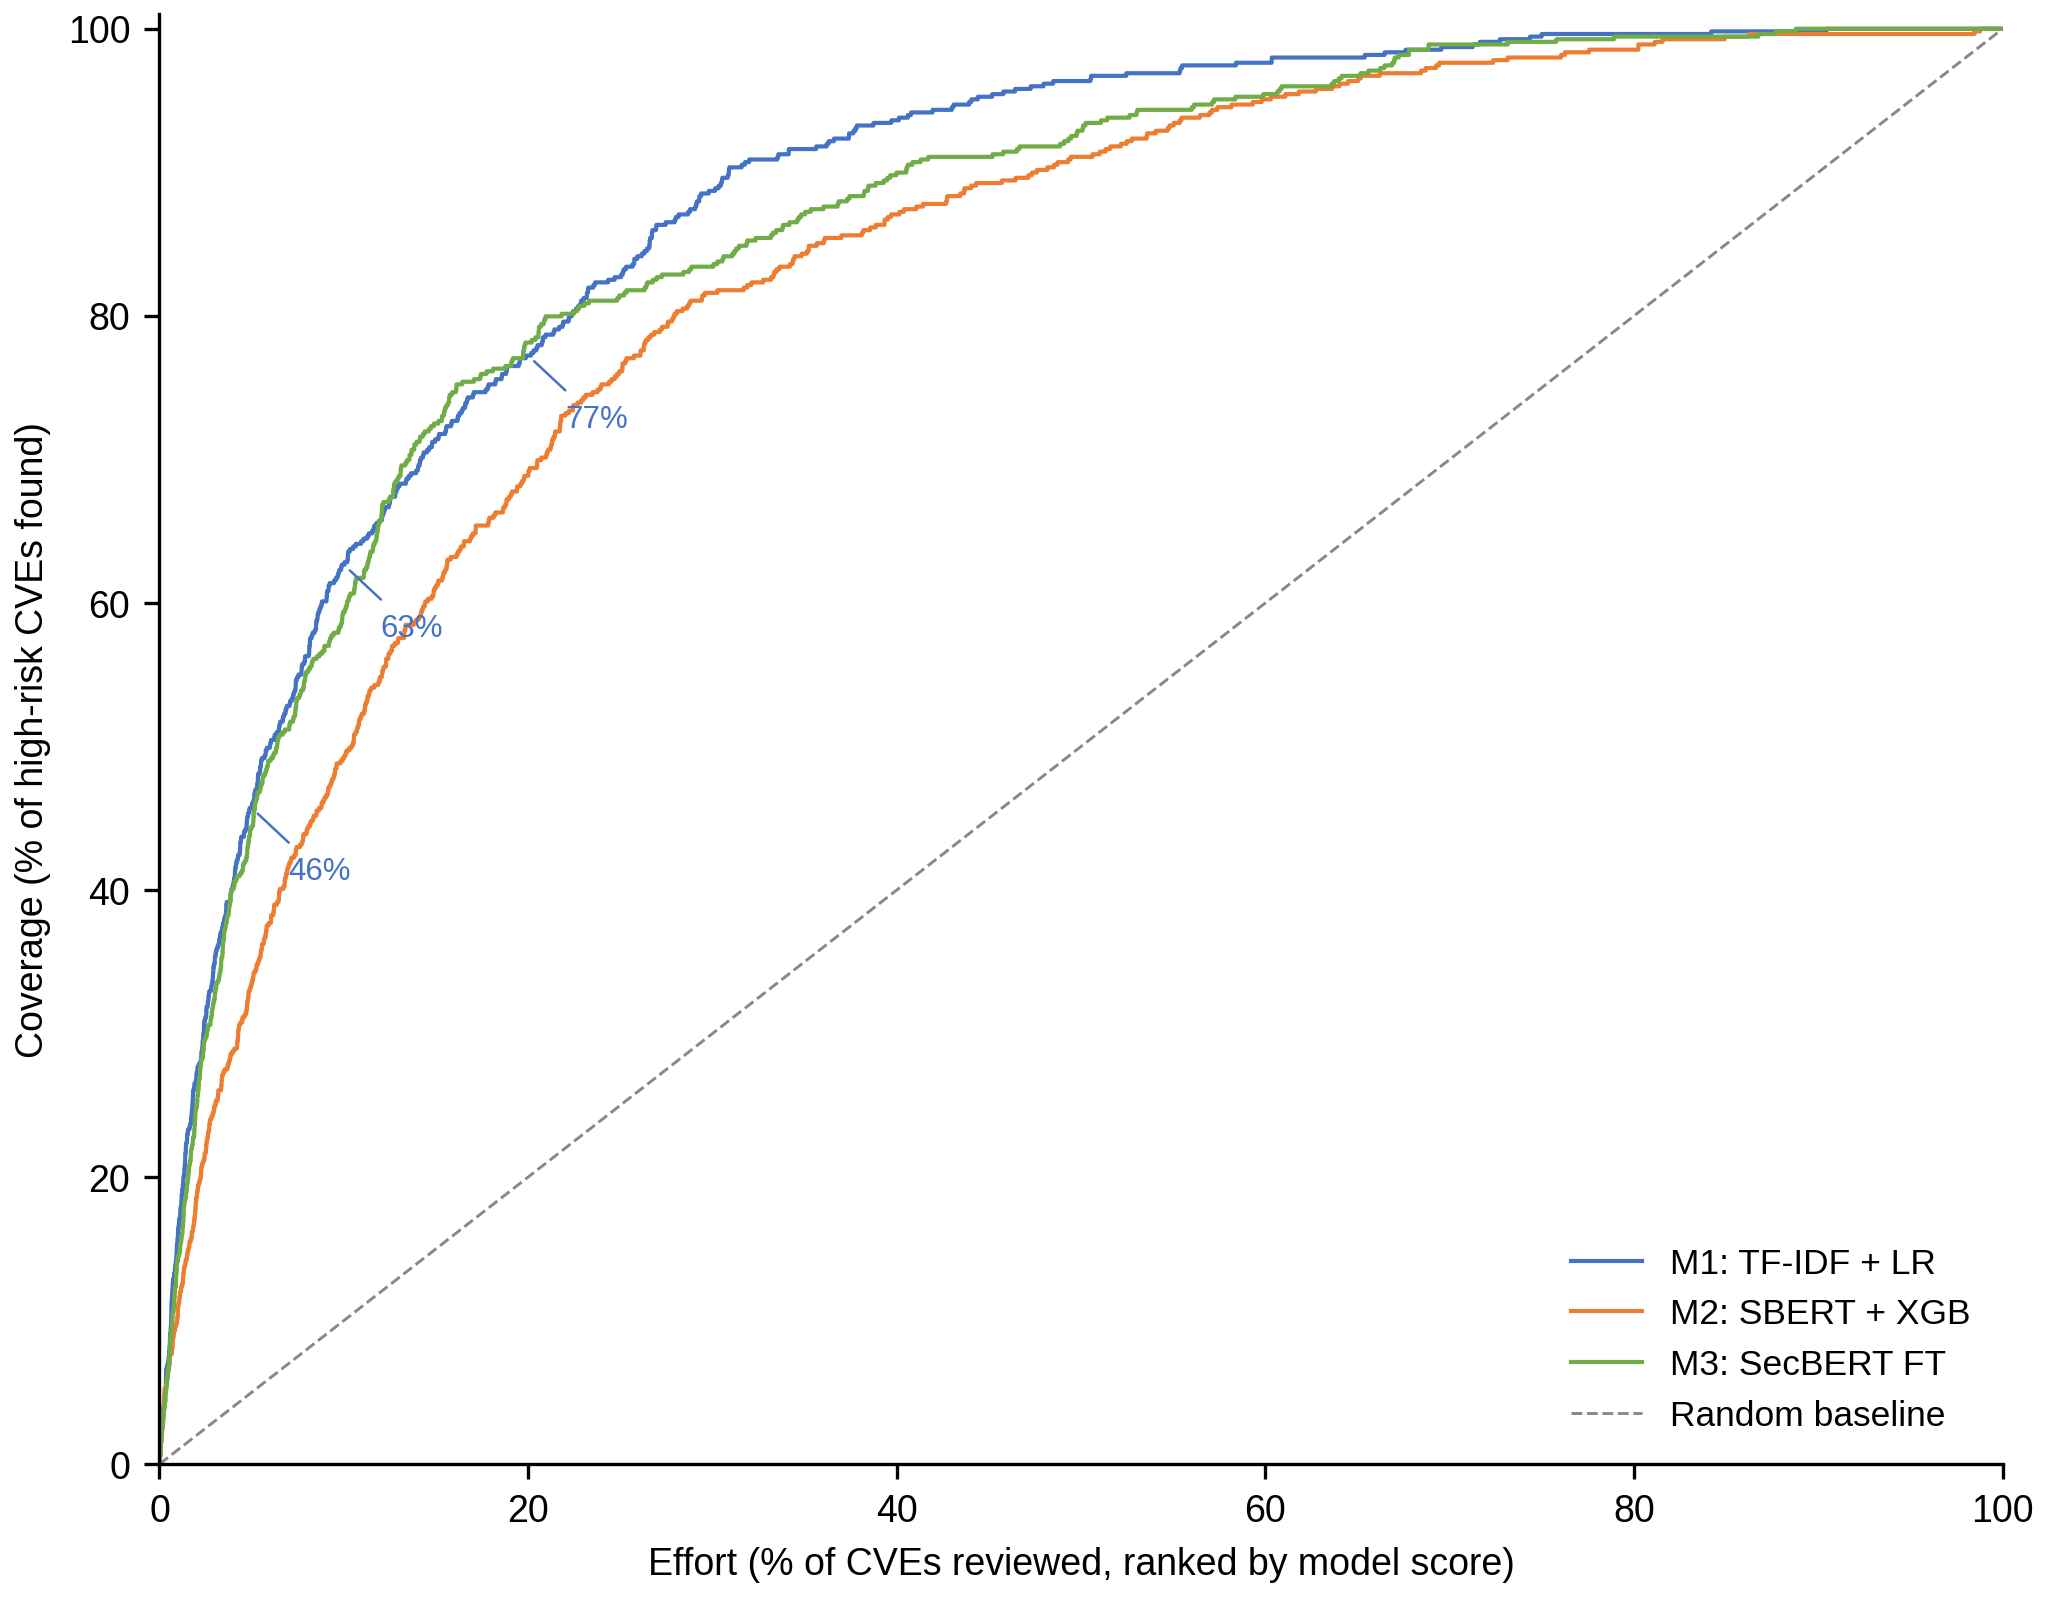

Figure 11 saved.


In [5]:

# ── CELL 5: Figure 11 — Effort-Coverage curve ────────────────
fig11, ax = plt.subplots(figsize=(7, 5.5))

effort_m1, cov_m1 = effort_coverage(y_test, m1_probs)
ax.plot(effort_m1, cov_m1, color=C_BLUE, lw=1.0,
        label="M1: TF-IDF + LR")

if has_m2:
    effort_m2, cov_m2 = effort_coverage(y_test, m2_probs)
    ax.plot(effort_m2, cov_m2, color=C_ORANGE, lw=1.0,
            label="M2: SBERT + XGB")

if has_m3:
    effort_m3, cov_m3 = effort_coverage(y_test, m3_probs)
    ax.plot(effort_m3, cov_m3, color=C_GREEN, lw=1.0,
            label="M3: SecBERT FT")

# Random baseline (diagonal)
ax.plot([0, 100], [0, 100], color=C_GREY, lw=0.7,
        linestyle="--", label="Random baseline")

# Annotate key points for M1
for k_pct in [5, 10, 20]:
    effort_val = k_pct
    idx = np.searchsorted(effort_m1, effort_val)
    if idx < len(cov_m1):
        ax.annotate(f"{cov_m1[idx]:.0f}%",
                    xy=(effort_val, cov_m1[idx]),
                    xytext=(effort_val + 2, cov_m1[idx] - 5),
                    fontsize=7.5, color=C_BLUE,
                    arrowprops=dict(arrowstyle="-",
                                    color=C_BLUE, lw=0.6))

ax.set_xlabel("Effort (% of CVEs reviewed, ranked by model score)")
ax.set_ylabel("Coverage (% of high-risk CVEs found)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 101)
ax.legend(loc="lower right", fontsize=8.5)

plt.tight_layout()
plt.savefig(DATA_DIR / "fig11_effort_coverage.pdf")
plt.savefig(DATA_DIR / "fig11_effort_coverage.png", dpi=300)
plt.show()
print("Figure 11 saved.")



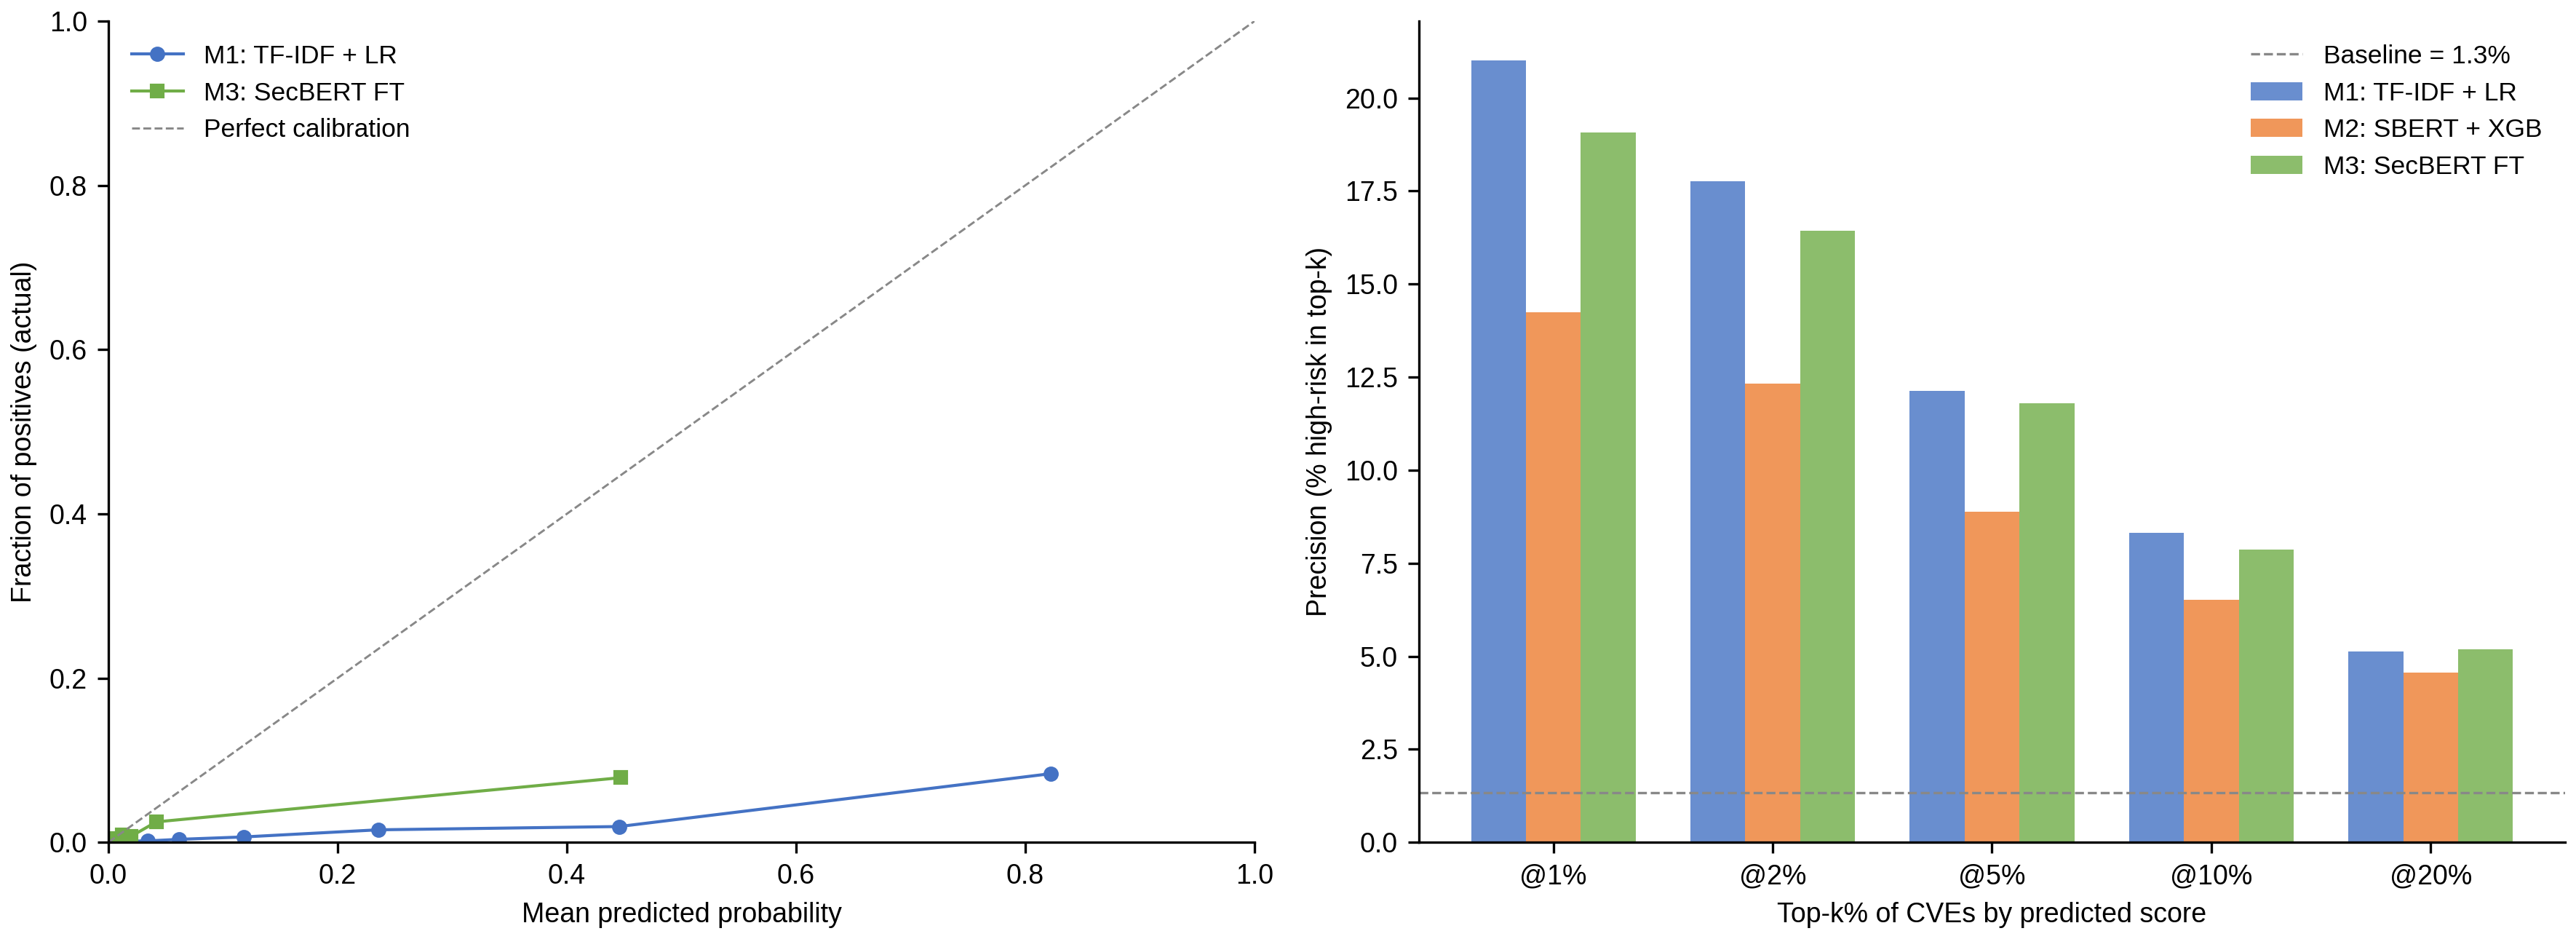

Figure 12 saved.


In [6]:

# ── CELL 6: Calibration curve ────────────────────────────────
from sklearn.calibration import calibration_curve

fig12, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: calibration curves
ax_cal = axes[0]
n_bins = 10

for name, probs, color in [
    ("M1: TF-IDF + LR", m1_probs, C_BLUE),
]:
    frac_pos, mean_pred = calibration_curve(
        y_test, probs, n_bins=n_bins, strategy="quantile")
    ax_cal.plot(mean_pred, frac_pos, color=color,
                marker="o", markersize=4, lw=1.0, label=name)

if has_m3:
    frac_pos3, mean_pred3 = calibration_curve(
        y_test, m3_probs, n_bins=n_bins, strategy="quantile")
    ax_cal.plot(mean_pred3, frac_pos3, color=C_GREEN,
                marker="s", markersize=4, lw=1.0,
                label="M3: SecBERT FT")

ax_cal.plot([0,1],[0,1], color=C_GREY, lw=0.7,
            linestyle="--", label="Perfect calibration")
ax_cal.set_xlabel("Mean predicted probability")
ax_cal.set_ylabel("Fraction of positives (actual)")
ax_cal.legend(fontsize=8.5)
ax_cal.set_xlim(0, 1); ax_cal.set_ylim(0, 1)

# Right: precision@k bar chart
ax_pk = axes[1]
k_pcts = [1, 2, 5, 10, 20]
bar_w = 0.25
x = np.arange(len(k_pcts))

m1_pk = [precision_at_k(y_test, m1_probs, k)[0]*100 for k in k_pcts]
ax_pk.bar(x, m1_pk, width=bar_w, color=C_BLUE,
          alpha=0.8, label="M1: TF-IDF + LR", edgecolor="none")

if has_m2:
    m2_pk = [precision_at_k(y_test, m2_probs, k)[0]*100 for k in k_pcts]
    ax_pk.bar(x + bar_w, m2_pk, width=bar_w, color=C_ORANGE,
              alpha=0.8, label="M2: SBERT + XGB", edgecolor="none")

if has_m3:
    m3_pk = [precision_at_k(y_test, m3_probs, k)[0]*100 for k in k_pcts]
    ax_pk.bar(x + 2*bar_w, m3_pk, width=bar_w, color=C_GREEN,
              alpha=0.8, label="M3: SecBERT FT", edgecolor="none")

ax_pk.axhline(base_rate*100, color=C_GREY, lw=0.8,
              linestyle="--",
              label=f"Baseline = {base_rate*100:.1f}%")
ax_pk.set_xticks(x + bar_w)
ax_pk.set_xticklabels([f"@{k}%" for k in k_pcts])
ax_pk.set_xlabel("Top-k% of CVEs by predicted score")
ax_pk.set_ylabel("Precision (% high-risk in top-k)")
ax_pk.legend(fontsize=8.5)

plt.tight_layout(pad=1.2)
plt.savefig(DATA_DIR / "fig12_calibration_precision_k.pdf")
plt.savefig(DATA_DIR / "fig12_calibration_precision_k.png", dpi=300)
plt.show()
print("Figure 12 saved.")



In [7]:

# ── CELL 7: Final summary ─────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY — New metrics for paper")
print("="*60)

print(f"\nPrecision@k for M1 (baseline = {base_rate*100:.2f}%):")
for k_pct in [1, 2, 5, 10, 20]:
    prec, k_n = precision_at_k(y_test, m1_probs, k_pct)
    lift = prec / base_rate
    print(f"  @{k_pct:2d}% (top {k_n:,} CVEs): "
          f"Precision={prec*100:.1f}%  Lift={lift:.1f}x")

print(f"\nEffort-Coverage for M1:")
for k_pct in [5, 10, 20]:
    idx = np.searchsorted(effort_m1, k_pct)
    print(f"  Review top {k_pct}% of CVEs → "
          f"find {cov_m1[min(idx,len(cov_m1)-1)]:.0f}% "
          f"of all high-risk")

print("\nFigures saved:")
print("  fig11_effort_coverage.png / .pdf")
print("  fig12_calibration_precision_k.png / .pdf")




SUMMARY — New metrics for paper

Precision@k for M1 (baseline = 1.33%):
  @ 1% (top 414 CVEs): Precision=21.0%  Lift=15.9x
  @ 2% (top 828 CVEs): Precision=17.8%  Lift=13.4x
  @ 5% (top 2,070 CVEs): Precision=12.1%  Lift=9.1x
  @10% (top 4,141 CVEs): Precision=8.3%  Lift=6.3x
  @20% (top 8,282 CVEs): Precision=5.1%  Lift=3.9x

Effort-Coverage for M1:
  Review top 5% of CVEs → find 46% of all high-risk
  Review top 10% of CVEs → find 63% of all high-risk
  Review top 20% of CVEs → find 77% of all high-risk

Figures saved:
  fig11_effort_coverage.png / .pdf
  fig12_calibration_precision_k.png / .pdf

Next: Step 3 — SecBERT full dataset (colab_step3_secbert_full.py)
